<a href="https://colab.research.google.com/github/Leo-Mtz/mineria-de-datos/blob/main/mineria_de_datos_cuadernoP2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skeletal Variation

[Project extensions are at the bottom of this file]

The comparison of skeletons across species lead to historical insights in evolutionary biology. In this project, you will explore the bones of the human body and make comparisons to a wide variety of mammals and birds.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Loading the Data

The file `'adult-human-skeleton.csv'` contains information about every bone in the human body.
Load the csv data and take a look.

Activity Goals:
- Import pandas.
- Load the skeleton data.
- Display the dataframe.

In [ ]:
import pandas as pd
df = pd.read_csv('adult-human-skeleton.csv')
df #display the dataframe

,name,region,subregion,side,fused_from
0,frontal,head,cranium,center,2
1,left parietal,head,cranium,left,1
2,right parietal,head,cranium,right,1
3,left temporal,head,cranium,left,1
4,right temporal,head,cranium,right,1
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


Each row represents one bone in the adult human body. We can see that adults have 206 bones. What can we learn about these bones?

### Claim: Half the bones are in the hands and feet

You might have heard the claim that over half the bones in your body are found in your hands and feet. Is this claim true or is it an urban legend?

Let's see how many bones are in each region using the `value_counts()` method.

Activity Goal:
- Find the counts for each value in the 'region' column.

In [ ]:
df['region'].value_counts()

,count
region,
hand,54
foot,52
torso,50
head,28
neck,8
leg,8
arm,6


The hands have a total of 54 bones ,and the feet have 52 bones.

Earlier we saw that the entire body has 206 bones. Using python, we can calculate what proportion are in the hands and feet. Run the code below:

In [ ]:
(54 + 52) / 206

0.5145631067961165

Over 51% of bones are found in the hands and feet. The claim is true!

### Baby bones

Infants have more bones than adults, but as the baby develops, groups of bones fuse together. This is detailed in the `'fused_from'` column of our data.

Let's sort the values in this `'fused_from'` column.

Activity Goals:
- Sort the dataframe by the `'fused_from'` column.
- Use descending order.

In [ ]:
df.sort_values(by='fused_from', ascending=False)

,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
30,c2,neck,vertebra,center,5
82,sacrum,torso,pelvis,center,5
5,occipital,head,cranium,center,4
83,coccyx,torso,pelvis,center,4
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


This shows a wide variety of bone fusion across the body. For example, the sternum is formed from the fusion of 6 bones.

Before all this fusion takes place, how many bones do infants have? We can answer this by calculating the `sum()` of all the fused_from values.

Activity Goals:
- Select the `'fused_from'` column.
- Add up all values in that column.

In [ ]:
df['fused_from'].sum()

np.int64(305)

Human infants have 305 bones, many of which fuse together, resulting in 206 bones in the adult body.

### Human neck bones

Necks are quite flexible. How many bones are in the human neck to allow for that flexibility?

Let's use the `query()` method to find out.

Activity Goal:
- Find all rows where the region is 'neck'.

In [ ]:
df.query('region == "neck"')

,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


The neck has 1 throat bone, and a stack of 7 neck vertebrae, named C1 through C7. The "C" stands for cervical, meaning neck. These 7 cervical vertebrae form the top of the spinal column.

So, humans have 7 neck vertebrae. What about other mammals?

### Mammal neck bones

This project includes the <code>'mammal-neck-bones.csv'</code> file. Let's load it so we can explore the necks of other mammals.

Activity Goals:
- Load the mammal neck data.
- Display it.

In [ ]:
mammals = pd.read_csv('mammal-neck-bones.csv')
mammals #display the dataframe

,species,neck_vertebrae
0,cheetah,7
1,impala,7
2,giant panda,7
3,hartebeest,7
4,moose,7
...,...,...
297,alpaca,7
298,common wombat,7
299,red fox,7
300,fennec fox,7


The rows shown above all have 7 neck vertebrae, but is this true for all 302 mammals in this dataset? Let's use a `query()` to find the data for giraffes, which we know have really long necks.

Activity Goal:
- Show rows where the species is 'giraffe'.

In [ ]:
mammals.query('species == "giraffe"')

,species,neck_vertebrae
108,giraffe,7


Despite their very long necks, giraffes also have 7 neck vertebrae!

So, do all mammals have 7 vertebrae? We can use another `query()` to search for any rows where neck_vertebrae is not 7.

Activity Goal:
- Search for rows where the number of vertebrae does not equal 7.

In [ ]:
mammals.query('neck_vertebrae != 7')

,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


Aha! It looks like the only mammals without 7 vertebrae are manatees and sloths.

### Bird neck bones

While mammals mostly have 7 neck vertebrae, what about birds? Let's load in `'bird-neck-bones.csv'` to explore.

Activity Goals:
- Load the bird neck data.
- Display it.

In [ ]:
birds = pd.read_csv('bird-neck-bones.csv')
birds #display the dataframe

,species,neck_vertebrae
0,cinereous vulture,13
1,guineafowl,14
2,red-legged partridge,14
3,blue-cheeked parrot,12
4,northern pintail,15
...,...,...
76,barn owl,12
77,eurasian hoopoe,13
78,murre,13
79,new zealand rockwren,13


Birds seem to have many more vertebrae than mammals. Let's make a bar plot of the value counts to get a sense of the distribution.

We will use the method `sort_index()` to sort the value counts by the number of neck vertebrae.

Activity Goals:
- Get the value counts for bird neck vertebrae.
- Sort by the index.
- Use pandas to make a bar plot.

<Axes: xlabel='neck_vertebrae'>

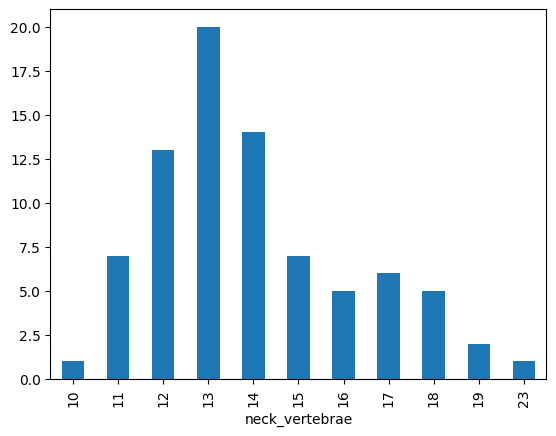

In [ ]:
bird_counts = birds['neck_vertebrae'].value_counts()
bird_counts = bird_counts.sort_index()
bird_counts.plot.bar()


Birds have more diverse neck skeletons.

The most common number of neck vertebrae is 13, but it looks like 23 is the maximum.

Which bird has the maximum number of neck bones?

Activity Goal:
- Find the rows with the maximum number of neck vertebrae.

In [ ]:
birds.query('neck_vertebrae == neck_vertebrae.max()')

,species,neck_vertebrae
28,mute swan,23


The beautiful Mute Swan takes the prize!

## Project extensions

Below are a few ideas for extensions.

1. Which bird has the fewest neck vertebra?

	- Find the row with the minimum number of neck vertebrae.

2. Do humans have more bones in the arms or legs?

	- Filter the rows where the region is `arm`.
	- Repeat with `leg`.

3. How many ribs to humans have?

	- Filter the rows where the name contains the word `rib`.

		- Hint: `name.str.contains("rib")`.

	- To count the number of rows, use the dataframe function `df.shape`.

	- This will return the number of rows and columns in the dataframe.

In [ ]:
# Extension 1: Which bird has the fewest neck vertebrae?
birds.query('neck_vertebrae == neck_vertebrae.min()')

,species,neck_vertebrae
11,blue-and-yellow macaw,10


In [ ]:
# Extension 2: Do humans have more bones in the arms or legs?

# Bones in the arms
arm_bones = df.query('region == "arm"')
print(f"Arm bones: {arm_bones.shape[0]}")
arm_bones

Arm bones: 6


,name,region,subregion,side,fused_from
86,left humerus,arm,upper-arm,left,3
87,right humerus,arm,upper-arm,right,3
88,left radius,arm,lower-arm,left,2
89,right radius,arm,lower-arm,right,2
90,left ulna,arm,lower-arm,left,2
91,right ulna,arm,lower-arm,right,2


In [ ]:
# Bones in the legs
leg_bones = df.query('region == "leg"')
print(f"Leg bones: {leg_bones.shape[0]}")
leg_bones

Leg bones: 8


,name,region,subregion,side,fused_from
146,left femur,leg,upper-leg,left,3
147,right femur,leg,upper-leg,right,3
148,left patella,leg,knee,left,1
149,right patella,leg,knee,right,1
150,left tibia,leg,lower-leg,left,2
151,right tibia,leg,lower-leg,right,2
152,left fibula,leg,lower-leg,left,2
153,right fibula,leg,lower-leg,right,2


In [ ]:
# Extension 3: How many ribs do humans have?
ribs = df.query('name.str.contains("rib")')
print(f"Number of ribs: {ribs.shape[0]}")
ribs

Number of ribs: 24


,name,region,subregion,side,fused_from
41,left rib 1,torso,chest,left,1
42,left rib 2,torso,chest,left,1
43,left rib 3,torso,chest,left,1
44,left rib 4,torso,chest,left,1
45,left rib 5,torso,chest,left,1
46,left rib 6,torso,chest,left,1
47,left rib 7,torso,chest,left,1
48,left rib 8,torso,chest,left,1
49,left rib 9,torso,chest,left,1
50,left rib 10,torso,chest,left,1


# Our World Connected

[Project extensions are at the bottom of this file]

Cisco's technology forms the backbone of the Internet, connecting the world as a global community.

In this project, you will explore the rapid rise of the Internet and evaluate how close we are to a fully connected world.

### World internet users

The file `'world-internet-users.csv'` shows the number of Internet users by year. Here a user is defined as someone who has accessed the Internet within the last three months.

Activity Goals:
- Import pandas and matplotlib.
- Load the data.
- Display the dataframe.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
pd.options.display.max_rows = 6
pd.options.mode.chained_assignment = None
internet = pd.read_csv('/content/drive/MyDrive/world-internet-users.csv')
internet

,year,internet_users
0,1990,3000000
1,1991,4000000
2,1992,7000000
...,...,...
32,2022,5300000000
33,2023,5400000000
34,2024,5450000000


There are 35 rows of data, representing the years from 1990 to 2024.

In 1990, there were only 3 million Internet users.

In what year did the number of Internet users exceed 100 million? We can answer this question using the `query( )` method.

Activity Goals:
- Find rows where internet_users > 100 million.
- Show first result.


In [ ]:
exceeds_100M = internet.query('internet_users > 100e6')
exceeds_100M.head(1)

,year,internet_users
7,1997,120000000


Internet users went from 3 million in 1990 to over 100 million in 7 years.

That's a lot of people, but what percentage of the world's population does this represent? To answer this, we need to load in global population data.

### World population data

The file `historical-world-population.csv` contains world population estimates going back thousands of years. Load in the data and let's see how far back it goes.

Activity Goals:
- Load population data.
- Display the DataFrame.


In [ ]:
population = pd.read_csv('/content/drive/MyDrive/historical-world-population.csv')
population #display it

,year,population
0,-10000,4501152
1,-9000,5687125
2,-8000,7314623
...,...,...
122,2020,7887001284
123,2021,7954448405
124,2022,8021407170


The population estimates go back to the year 10,000 BCE!

Let's merge both dataframes together so we have both population and internet_users columns in one structure.

### Merge the data using 'left'

There are multiple ways to combine dataframes. When bringing together columns, we suggest using a left merge.

The `merge()` method allows you to specify the column to align on. In this case, we want to align on the `year` column.

This left merge will start with all years in the left dataframe, and ignore any extra years from the right dataFrame. This is useful here becase we are not interested in all the years before 1990 going back to 10,000 BCE!

Activity Goals:
- Merge internet and population data.
- Use a left merge on the `year` column.
- Display the results.


In [ ]:
df = internet.merge(population, on='year', how='left')
df #display

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
32,2022,5300000000,8.021407e+09
33,2023,5400000000,NaN
34,2024,5450000000,NaN


Notice how we kept all 35 years of internet_user data, but the last two rows have population values of `NaN`.

Here `NaN` stands for Not a Number, and indicates that no matching population data was found for the years 2023 and 2024. Those last two years were not in the right DataFrame.

Let's drop these incomplete rows using the `dropna( )` method. This way the `NaN` values won't interfere with our analysis.

Activity Goals:
- Drop rows with NaNs.
- Display the dataframe.

In [ ]:
df = df.dropna()
df #display it

,year,internet_users,population
0,1990,3000000,5.327803e+09
1,1991,4000000,5.418736e+09
2,1992,7000000,5.505990e+09
...,...,...,...
30,2020,4700000000,7.887001e+09
31,2021,4901000000,7.954448e+09
32,2022,5300000000,8.021407e+09


Looks like it worked. The updated df now has only 33 rows.

### Percent of world using internet

We're now ready to calculate the percent of the global population connected to the Internet for each year. We will use the `eval()` method.

Activity Goals:
- Calculate percent connected to internet.
- Round it to 2 decimal places.
- Display the dataframe.

In [ ]:
df['percent'] = df.eval('internet_users/population * 100')
df['percent'] = df['percent'].round(2)
df #display the result

,year,internet_users,population,percent
0,1990,3000000,5.327803e+09,0.06
1,1991,4000000,5.418736e+09,0.07
2,1992,7000000,5.505990e+09,0.13
...,...,...,...,...
30,2020,4700000000,7.887001e+09,59.59
31,2021,4901000000,7.954448e+09,61.61
32,2022,5300000000,8.021407e+09,66.07


In 1990 less than 0.1% of the world used the Internet, but by 2022 over 65% were connected.

When did the internet surpass half the population?

### Half the world connected
Let's plot the percentage of Internet users over time. We'll use the `axhline( )` method to draw a horizontal axis line at the 50% mark. This will give us a visual estimate of when internet use first passed 50%.

Activity Goals:
- Plot percent connected over time.
- Add a gray horizontal line at 50%.
- Label both axes.


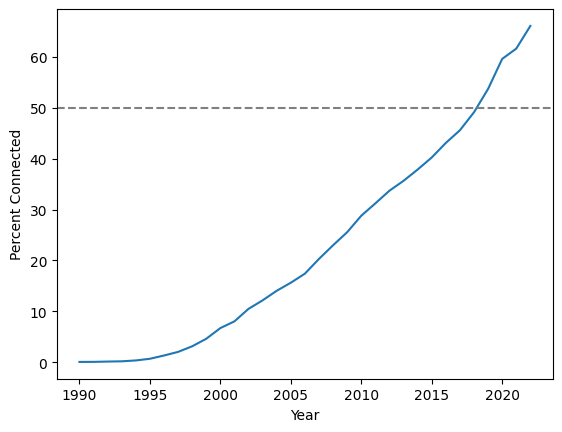

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df['year'], df['percent'])
plt.axhline(50, color='gray', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Percent Connected')
plt.show()

The graph shows that over 50% of the world became connected to the internet by 2020.

### Finding the year we crossed 50%

Plotting the data provides a visual estimate of the year the world crossed 50% internet connected. Now let's use the `query( )` and `head( )` methods to find the crossing point in our data.



In [ ]:
over_half_connected = df.query('percent >= 50')
over_half_connected.head(1)

,year,internet_users,population,percent
29,2019,4194000000,7.811294e+09,53.69


The first year to surpass 50% was 2019.

While the Internet has grown exponentially, we still have work to do to ensure we are all connected as a global community.

## Project extensions

The file `extension-internet-users-by-continent.csv` provides data on the number of internet users across each continent, while the file `extension-historical-population-by-continent.csv` details historical population counts for each continent.

Here are some suggested extensions for your project:

1. Determine the year when more than 50% of the population in a continent of your choice first gained internet access.

2. Explore and analyze internet usage and population data for a specific region or country of interest, such as by sourcing information from sites like ourworldindata.org.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'extension-internet-users-by-continent.csv' and 'extension-historical-population-by-continent.csv'.

# from google.colab import files
# uploaded = files.upload()

In [ ]:
population_by_continent = pd.read_csv('/content/drive/MyDrive/extension-historical-population-by-continent.csv')
population_by_continent

,continent,year,population
0,Africa,-10000,1118546
1,Africa,-9000,1214579
2,Africa,-8000,1355402
...,...,...,...
1587,South America,2021,428331420
1588,South America,2022,430492814
1589,South America,2023,433024230


In [ ]:
internet_users_by_continent = pd.read_csv('/content/drive/MyDrive/extension-internet-users-by-continent.csv')
internet_users_by_continent

,continent,year,internet_users
0,Africa,1990,0.000000e+00
1,Africa,1991,5.537650e+03
2,Africa,1992,1.649741e+04
...,...,...,...
189,South America,2019,2.815900e+08
190,South America,2020,3.102178e+08
191,South America,2021,3.177395e+08


In [ ]:
print("Internet users columns:", internet_users_by_continent.columns.tolist())
print("Population columns:", population_by_continent.columns.tolist())
print("Merged columns:", continent_df.columns.tolist())

Internet users columns: ['continent', 'year', 'internet_users']
Population columns: ['continent', 'year', 'population']
Merged columns: ['continent', 'year', 'internet_users', 'population']


Datos de Asia:


,year,internet_users,population,percent
32,1990,4.033261e+04,3209094416,0.00
33,1991,9.275652e+04,3268207591,0.00
34,1992,2.451233e+05,3324812376,0.01
...,...,...,...,...
61,2019,2.248639e+09,4651098712,48.35
62,2020,2.603488e+09,4686811205,55.55
63,2021,2.753528e+09,4716999175,58.37



Asia cruzó 50% en:


,year,internet_users,population,percent
62,2020,2.603488e+09,4686811205,55.55


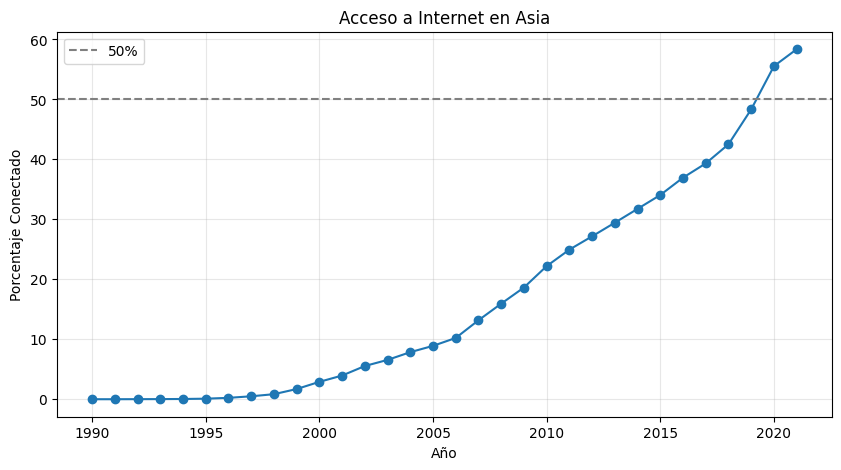

In [ ]:
# Extensión 1: ¿Cuándo un continente alcanzó 50% de acceso a internet?

# Unir datos por continente y año
continent_df = internet_users_by_continent.merge(population_by_continent, on=['continent', 'year'], how='left')

# Elegir continente
continent = 'Asia'

# Filtrar datos del continente
continent_data = continent_df.query('continent == @continent')[['year', 'internet_users', 'population']].copy()
continent_data = continent_data.dropna()

# Calcular porcentaje conectado
continent_data['percent'] = (continent_data['internet_users'] / continent_data['population'] * 100).round(2)

print(f"Datos de {continent}:")
display(continent_data)

# Buscar primer año >= 50%
over_50 = continent_data.query('percent >= 50')
if len(over_50) > 0:
    print(f"\n{continent} cruzó 50% en:")
    display(over_50.head(1))
else:
    print(f"\n{continent} aún no alcanza 50%.")

# Graficar
plt.figure(figsize=(10, 5))
plt.plot(continent_data['year'], continent_data['percent'], marker='o')
plt.axhline(50, color='gray', linestyle='--', label='50%')
plt.xlabel('Año')
plt.ylabel('Porcentaje Conectado')
plt.title(f'Acceso a Internet en {continent}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

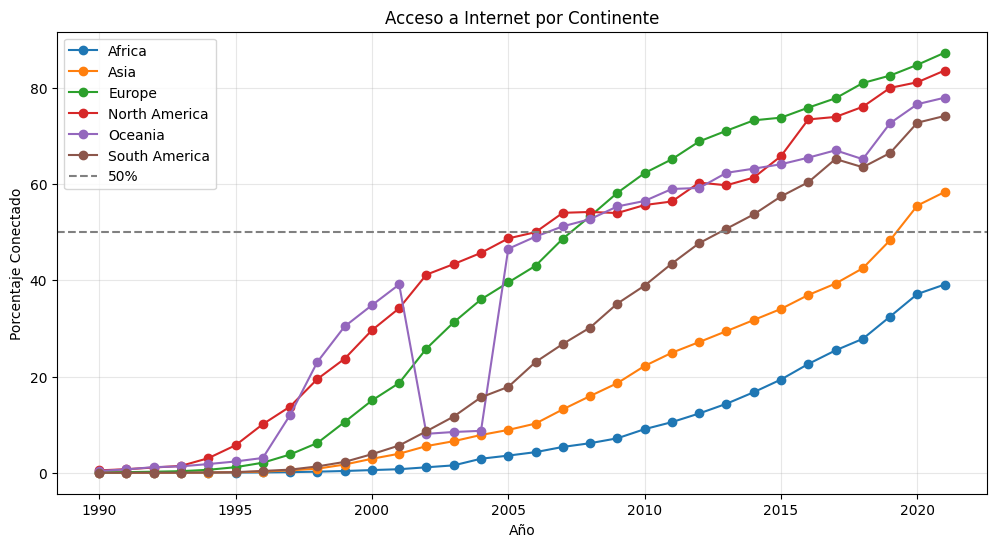

In [ ]:
# Extensión 2: Comparar todos los continentes

continent_df = internet_users_by_continent.merge(population_by_continent, on=['continent', 'year'], how='left')
continents = ['Africa', 'Asia', 'Europe', 'North America', 'Oceania', 'South America']

plt.figure(figsize=(12, 6))

for continent in continents:
    data = continent_df.query('continent == @continent')[['year', 'internet_users', 'population']].copy()
    data = data.dropna()
    data['percent'] = (data['internet_users'] / data['population'] * 100).round(2)

    plt.plot(data['year'], data['percent'], marker='o', label=continent)


plt.axhline(50, color='gray', linestyle='--', label='50%')
plt.xlabel('Año')
plt.ylabel('Porcentaje Conectado')
plt.title('Acceso a Internet por Continente')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

# Art as Data

[Project extensions are at the bottom of this file]

Piet Mondrian was a Dutch artist best known for his abstract, grid-like designs during the 1920s and 30s. Mondrian was part of an art movement that aimed to explore and express simplicity by using only the most basic colors and shapes.

How might we represent the features of a Mondrian painting using tabular data? Here is one approach:

| painting_id | feature | x   | y   | width | height | color  | rgb      |
|------------|---------|-----|-----|-------|--------|--------|----------|
| b219       | rect    | 0   | 0   | 121   | 152    | white  | #ffffff  |
| b219       | rect    | 132 | 0   | 378   | 365    | red    | #e6151a  |
| b219       | rect    | 0   | 173 | 121   | 192    | white  | #ffffff  |
| b219       | rect    | 0   | 377 | 121   | 133    | blue   | #2f5a9f  |
| b219       | rect    | 132 | 377 | 335   | 133    | white  | #ffffff  |
| b219       | rect    | 479 | 377 | 31    | 59     | white  | #ffffff  |
| b219       | rect    | 479 | 451 | 31    | 59     | yellow | #f7ed2d  |
| b219       | h-line  | 0   | 365 | 510   | 12     | black  | #000000  |
| b219       | v-line  | 121 | 0   | 11    | 510    | black  | #000000  |
| b219       | v-line  | 467 | 377 | 12    | 133    | black  | #000000  |
| b219       | h-line  | 0   | 152 | 121   | 21     | black  | #000000  |
| b219       | h-line  | 479 | 436 | 31    | 15     | black  | #000000  |

This table represents the features of the painting using 12 rows of data. Notice how each row represents a rectangular shape with x-y coordinates, size and color info.

By representing art as data, we open up artistic analysis to a broad range of data science techniques. In this project, we will explore Mondrian's quest for artistic simplicity and try our hands at detecting fake paintings falsely attributed to Mondrian.

### Loading the Data
The `mondrian-painting-features.csv` file contains digitized features for 136 Mondrian paintings over the 2 decades from 1920 to 1940. Load the data into python and take a look.

Activity Goals:
- Import pandas.
- Load the features data.
- Display the dataframe.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'mondrian-painting-features.csv', 'mondrian-painting-info.csv', and 'fp26-features.csv'.

# from google.colab import files
# uploaded = files.upload()

In [ ]:
import pandas as pd
pd.options.display.max_rows = 10

features = pd.read_csv('mondrian-painting-features.csv')
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
3199,b296,v-line,620,0,19,825,black,#000000
3200,b296,v-line,49,508,19,79,black,#000000
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000


The first painting in this dataset has an ID of b104. We can see that there are multiple rows with that same painting ID.

Let's use a `query` to extract all the features associated with that first painting.

Activity Goal:
- Find all the features for painting b104.

In [ ]:
features.query('painting_id == "b104"')

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
3,b104,rect,0,18,146,468,white,#cfd0ce
4,b104,rect,151,18,107,111,black,#151d16
...,...,...,...,...,...,...,...,...
36,b104,v-line,727,0,5,1007,black,#000000
37,b104,v-line,258,18,5,111,black,#000000
38,b104,v-line,531,134,5,809,black,#000000
39,b104,v-line,944,134,5,873,black,#000000


From this we see that painting b104 has 41 features.

We have got the features for this painting, but what if we are interested in the year it was painted?

For that, we need to load up a separate data file: `mondrian-painting-info.csv`.

Activity Goals:
- Load the painting info data.
- Display the dataframe.

In [ ]:
painting_info = pd.read_csv('mondrian-painting-info.csv')
painting_info

,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
3,b107,1920,Composition C,610,603
4,b108,1920,Composition I,646,750
...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052
132,b293,1939,"Composition of red, blue and white: II",330,435
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752


Each row represents one painting. Now we see that b104 was painted in the year 1920. Later, when we calculate painting metrics, we'll merge additional columns onto this `painting_info` dataframe.

### Turning Data into Pictures
For this project, we've provided the following function to draw Mondrian paintings from data:


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
def draw_mondrian( painting_id ):
    rects = features.query('painting_id == @painting_id')
    total_width = rects.eval("x + width").max()
    total_height = rects.eval("y + height").max()

    fig, ax = plt.subplots(figsize=(3, 3))

    for (idx, row) in rects.iterrows():
        x, y, w, h, rgb = row[['x','y','width','height','rgb']]
        patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
        ax.add_patch(patch)

    ax.axis([0, total_width, 0, total_height])
    ax.set_aspect('equal')
    ax.axis('off')
    fig.text(0.5, 0.01, painting_id, ha="center", fontsize=14)


Internally, this function uses Matplotlib to draw each feature as a rectangular patch of color. While the details of this function are not the focus of this project, feel free to take a look at the code to see how it works.

We can run this function any time we want to visualize a painting. For example, let's see what the first painting in our dataset (b104) looks like.

Activity Goal:
- Draw painting bl014.

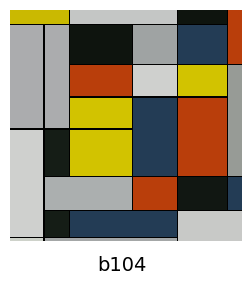

In [ ]:
draw_mondrian('b104')

We went from art to data and back again. Cool!

### Comparing Complexity

As mentioned earlier, Piet Mondrian was part of a movement to simplify artistic expression. Do Mondrian paintings vary substantially in their simplicity?

Let's use our `draw_mondrian()` function to draw two separate paintings and see if we notice any differences in complexity.

Activity Goal:
- Draw two separate Mondrain paintings.


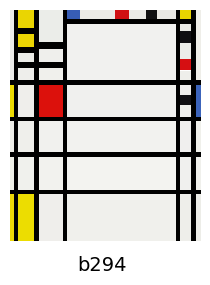

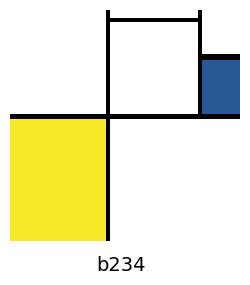

In [ ]:
draw_mondrian('b294')
draw_mondrian('b234')

The left painting is more complex due to having more horizontal lines, vertical lines, and rectangles.

### Quantifying Complexity
Art researchers have used a variety of approaches to quantify the complexity of Mondrian paintings. Perhaps the easiest method is to simply count the number of features in a given painting. Let's explore this basic metric and see if we encounter any interesting trends over time.

As a reminder, here is the `features` dataframe.

In [ ]:
pd.options.display.max_rows = 6
features

,painting_id,feature,x,y,width,height,color,rgb
0,b104,rect,0,0,146,13,white,#ced2ca
1,b104,rect,151,0,576,13,gray,#a4a7a7
2,b104,rect,732,0,278,129,gray,#c8c9c7
...,...,...,...,...,...,...,...,...
3201,b296,h-line,0,268,711,19,black,#000000
3202,b296,h-line,0,489,711,19,black,#000000
3203,b296,h-line,0,679,11,28,black,#000000


To count the number of features for each painting, let's use `df.groupby()`.

Activity Goals:
- Group the features by painting_id.
- Count the number of rows in each group.
- Display the counts.

In [ ]:
pd.options.display.max_rows = 10
sizes = features.groupby('painting_id').size()
sizes #display the result


painting_id
b104    41
b105    42
b106    41
b107    44
b108    44
        ..
b292    31
b293    26
b294    62
b295    47
b296    49
Length: 136, dtype: int64

This gives us the number of features for all 136 paintings. The output above is a 1-dimensional series where the index is the `painting_id`.

Let's turn the series into a dataframe by calling `reset_index( )`.

In [ ]:
complexity_df = sizes.reset_index(name='complexity')
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
3,b107,44
4,b108,44
...,...,...
131,b292,31
132,b293,26
133,b294,62
134,b295,47


This gives us a dataframe with the complexity (number of features) for each painting ID. null We now have complexity data for all 136 paintings.

### Merging Data
We want to plot complexity over time, but currently we have complexity in one dataframe and the year in a different dataframe.

In [ ]:
pd.options.display.max_rows = 6
complexity_df

,painting_id,complexity
0,b104,41
1,b105,42
2,b106,41
...,...,...
133,b294,62
134,b295,47
135,b296,49


In [ ]:
painting_info


,painting_id,year,title,width,height
0,b104,1920,No. VI,1010,1007
1,b105,1920,Composition A,918,900
2,b106,1920,Composition B,575,677
...,...,...,...,...,...
133,b294,1939,Trafalgar Square,1200,1452
134,b295,1939,Composition no. 8,681,752
135,b296,1940,Composition no. 11,711,825


Let's add the complexity data into the `painting_info` dataframe using a left merge. This will allow us to plot how complexity changes by year.

Merging dataframes in Pandas is like joining tables in SQL. We need to specify which columns will be used to find matching rows. In our case, each row for both dataframes represents a single painting. Rows can be matched using the `painting_id` column.

Activity Goals:
- Merge `complexity_df` into `painting_info`.
- Display the result.

In [ ]:
pd.options.display.max_rows = 10
painting_info = painting_info.merge(complexity_df, on='painting_id', how='left')
painting_info

,painting_id,year,title,width,height,complexity
0,b104,1920,No. VI,1010,1007,41
1,b105,1920,Composition A,918,900,42
2,b106,1920,Composition B,575,677,41
3,b107,1920,Composition C,610,603,44
4,b108,1920,Composition I,646,750,44
...,...,...,...,...,...,...
131,b292,1939,Composition no. 1,1023,1052,31
132,b293,1939,"Composition of red, blue and white: II",330,435,26
133,b294,1939,Trafalgar Square,1200,1452,62
134,b295,1939,Composition no. 8,681,752,47


We have now merged the `complexity_df` into `painting_info`.

### Plotting Complexity over Time
Are you ready to make some graphs?

Let's visualize how complexity changes over the years for these Mondrian paintings. A scatterplot would work well for this.

Activity Goals:
- Import matplotlib.pyplot.
- Create a scatterplot of complexity over time.
- Label the axes.

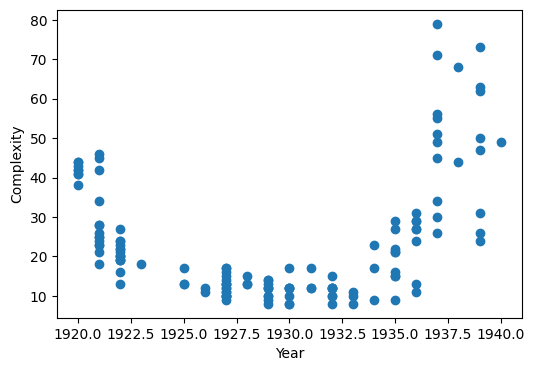

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()

The complexity of Mondrian's paintings increases after 1935, indicating a shift in his artistic style.

### Detecting Possible Fake Paintings
Since Mondrian paintings can sell for millions of dollars, it's not hard to imagine that someone might try to create a forgery. The following is a widely shared painting claimed to be a Mondrian artwork from 1926.

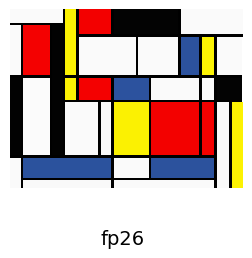

In [ ]:
# code to plot the figure
rects = pd.read_csv('fp26-features.csv')
total_width = rects.eval("x + width").max()
total_height = rects.eval("y + height").max()

fig, ax = plt.subplots(figsize=(3, 3))

for (idx, row) in rects.iterrows():
	x, y, w, h, rgb = row[['x','y','width','height','rgb']]
	patch = mpatches.Rectangle((x, y), w, h, facecolor=rgb)
	ax.add_patch(patch)

ax.axis([0, total_width, 0, total_height])
ax.set_aspect('equal')
ax.axis('off')
fig.text(0.5, 0.01, 'fp26', ha="center", fontsize=14)
plt.show()


This painting doesn't show up in our catalog. Is it real or fake? Let's see what evidence we can glean from the data.

Load up the feature data for this painting from the file `fp26-features.csv`.

Activity Goals:
- Load the features for fake painting 1926.
- Display the Dataframe.

In [ ]:
fp26_features = pd.read_csv('fp26-features.csv')
fp26_features

,painting_id,feature,x,y,width,height,color,rgb
0,fp26,rect,0,0,34,92,white,#fafafa
1,fp26,rect,41,0,267,22,white,#f9f9f9
2,fp26,rect,317,0,309,22,white,#fafafa
3,fp26,rect,634,0,38,261,white,#fafafa
4,fp26,rect,680,0,32,261,yellow,#fcf202
...,...,...,...,...,...,...,...,...
49,fp26,h-line,206,462,506,8,black,#000000
50,fp26,h-line,0,497,166,8,black,#000000
51,fp26,v-line,270,96,9,169,black,#000000
52,fp26,v-line,580,96,7,370,black,#000000


Using our number of features metric for complexity, we can see that this painting has a complexity of 54.

Is a complexity of 54 consistent with other Mondrain paintings in the year 1926? Let's add this datapoint to our scatterplot for a visual comparison.

Activity Goals:
- Recreate the scatterplot from earlier.
- Plot the new point as a red square.
- Label the axes.

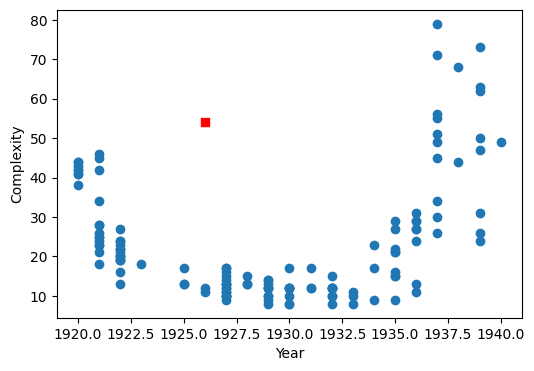

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(painting_info['year'], painting_info['complexity'])
plt.scatter(x=1926, y=54, color='red', marker='s')
plt.xlabel('Year')
plt.ylabel('Complexity')
plt.show()


The 1926 painting is an outlier with much higher complexity than other paintings from that period, suggesting it might be a fake.


## Project extensions

Here are some ideas for extending the project:

1. **Analyze painting dimensions over time**  
    
    Plot the length, width, or area of each painting against its creation date. Are there any noticeable trends or patterns?

2. **Track blue color usage over time**  
   - Compute the total area of each painting using data from `painting_info`.  

   - Identify features in the dataset where the color is 'blue'.

   - Calculate the area of these blue features.  

   - Group the blue feature areas by `painting_id` and sum them.

   - Merge this data with `painting_info`.  

   - Plot the percentage of blue in each painting over time.

   - Repeat with other colors (red, yellow, white, black, gray)

In [ ]:
# Extensión 1: Analizar dimensiones de pinturas a lo largo del tiempo

# painting_info ya tiene columnas 'length' y 'width'
# Calcular área de cada pintura
painting_info['area'] = painting_info['length'] * painting_info['width']

# Crear 3 gráficas: largo, ancho y área
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Gráfica de largo vs año
axes[0].scatter(painting_info['year'], painting_info['length'])
axes[0].set_xlabel('Año')
axes[0].set_ylabel('Largo (px)')
axes[0].set_title('Largo de pinturas')

# Gráfica de ancho vs año
axes[1].scatter(painting_info['year'], painting_info['width'])
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Ancho (px)')
axes[1].set_title('Ancho de pinturas')

# Gráfica de área vs año
axes[2].scatter(painting_info['year'], painting_info['area'])
axes[2].set_xlabel('Año')
axes[2].set_ylabel('Área (px²)')
axes[2].set_title('Área de pinturas')

plt.tight_layout()
plt.show()

In [ ]:
# Extensión 2: Rastrear uso de colores a lo largo del tiempo

# Calcular área de cada feature
features['feature_area'] = features['width'] * features['height']

# Calcular área total por pintura
total_area = features.groupby('painting_id')['feature_area'].sum().reset_index(name='total_feature_area')

# Unir área total a painting_info
painting_info = painting_info.merge(total_area, on='painting_id', how='left')

# Función para calcular porcentaje de un color
def calc_color_percent(color_name):
    # Filtrar features de ese color
    color_features = features.query('color == @color_name')

    # Sumar área por pintura
    color_area = color_features.groupby('painting_id')['feature_area'].sum().reset_index(name=f'{color_name}_area')

    return color_area

# Calcular área para cada color
colors = ['blue', 'red', 'yellow', 'white', 'black', 'gray']

for color in colors:
    color_area = calc_color_percent(color)
    painting_info = painting_info.merge(color_area, on='painting_id', how='left')
    # Llenar NaN con 0 (pinturas sin ese color)
    painting_info[f'{color}_area'] = painting_info[f'{color}_area'].fillna(0)
    # Calcular porcentaje
    painting_info[f'{color}_percent'] = (painting_info[f'{color}_area'] / painting_info['total_feature_area'] * 100).round(2)

# Mostrar resultado
painting_info[['painting_id', 'year'] + [f'{c}_percent' for c in colors]]

In [ ]:
# Graficar porcentaje de cada color vs año
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, color in enumerate(colors):
    axes[i].scatter(painting_info['year'], painting_info[f'{color}_percent'], alpha=0.6)
    axes[i].set_xlabel('Año')
    axes[i].set_ylabel(f'% {color}')
    axes[i].set_title(f'Uso de {color} en el tiempo')

plt.tight_layout()
plt.show()

In [ ]:
# Graficar todos los colores en una sola figura
plt.figure(figsize=(10, 6))

for color in colors:
    plt.scatter(painting_info['year'], painting_info[f'{color}_percent'], label=color, alpha=0.6)

plt.xlabel('Año')
plt.ylabel('Porcentaje del área')
plt.title('Uso de colores en pinturas de Mondrian')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green?

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("/content/drive/MyDrive/munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

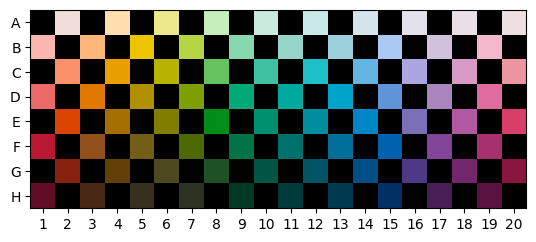

In [ ]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

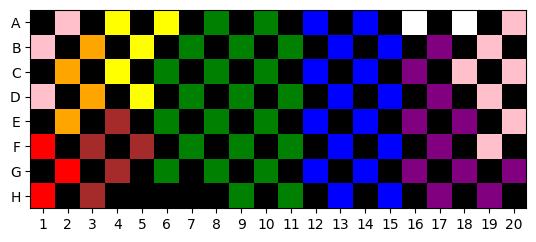

In [ ]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots.
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

	- You might need to `merge` dataframes.


In [ ]:
# Calculo de porcentaje de cada lenguaje
def get_color_percentages(column_name):
    counts = df[column_name].value_counts()
    percentages = (counts / len(df) * 100).reset_index()
    percentages.columns = ['color', 'percentage']
    return percentages

# Creacion de dataframe
english_pct = get_color_percentages('english_color')
spanish_pct = get_color_percentages('spanish_color')
tsimane_pct = get_color_percentages('tsimane_color')

# Dataframes por lenguaje
print("Porcentaje de colores en ingles:")
display(english_pct)

print("\nPorcentaje de colores en espanol:")
display(spanish_pct)

print("\nPorcentaje de colores en Tsimane:")
display(tsimane_pct)

Porcentaje de colores en ingles:


,color,percentage
0,green,27.50
1,blue,20.00
2,purple,13.75
3,pink,12.50
4,yellow,6.25
5,brown,6.25
6,orange,5.00
7,red,3.75
8,black,2.50
9,white,2.50



Porcentaje de colores en espanol:


,color,percentage
0,green,27.50
1,lightblue,13.75
2,purple,13.75
3,pink,10.00
4,white,7.50
5,red,5.00
6,orange,5.00
7,yellow,5.00
8,brown,5.00
9,blue,5.00



Porcentaje de colores en Tsimane:


,color,percentage
0,green,25.00
1,blue,15.00
2,yellow,13.75
3,purple,12.50
4,white,11.25
5,red,10.00
6,brown,8.75
7,black,3.75


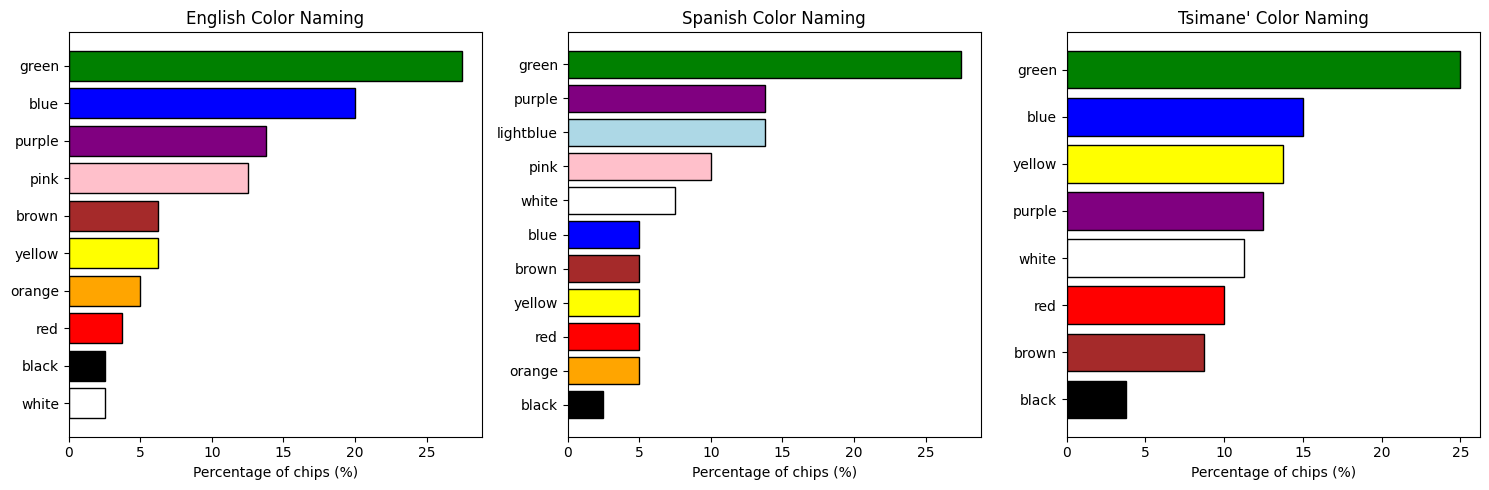

In [ ]:
# Sort dataframes from smallest to biggest (so biggest appears at top in horizontal bar chart)
english_sorted = english_pct.sort_values('percentage', ascending=True)
spanish_sorted = spanish_pct.sort_values('percentage', ascending=True)
tsimane_sorted = tsimane_pct.sort_values('percentage', ascending=True)

# Create horizontal bar charts for each language
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# English bar chart
axes[0].barh(english_sorted['color'], english_sorted['percentage'],
             color=english_sorted['color'], edgecolor='black')
axes[0].set_xlabel('Porcentaje %')
axes[0].set_title('Ingles')

# Spanish bar chart
axes[1].barh(spanish_sorted['color'], spanish_sorted['percentage'],
             color=spanish_sorted['color'], edgecolor='black')
axes[1].set_xlabel('Porcentaje %')
axes[1].set_title('Español')

# Tsimane' bar chart
axes[2].barh(tsimane_sorted['color'], tsimane_sorted['percentage'],
             color=tsimane_sorted['color'], edgecolor='black')
axes[2].set_xlabel('Porcentaje %')
axes[2].set_title("Tsimane")

plt.tight_layout()
plt.show()

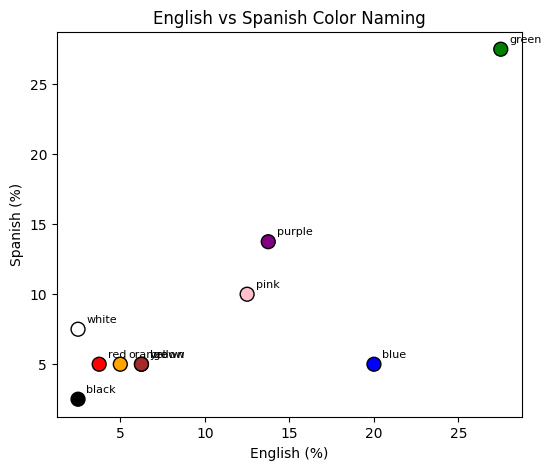

In [ ]:
# Merge de dataframes de español e ingles
eng_spa = english_pct.merge(spanish_pct, on='color', suffixes=('_english', '_spanish'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(eng_spa['percentage_english'], eng_spa['percentage_spanish'],
            c=eng_spa['color'], edgecolors='black', s=100)

for _, row in eng_spa.iterrows():
    plt.annotate(row['color'], (row['percentage_english'] + 0.5, row['percentage_spanish'] + 0.5), fontsize=8)

plt.xlabel('Ingles (%)')
plt.ylabel('Español (%)')
plt.title('Ingles vs Español')
plt.show()

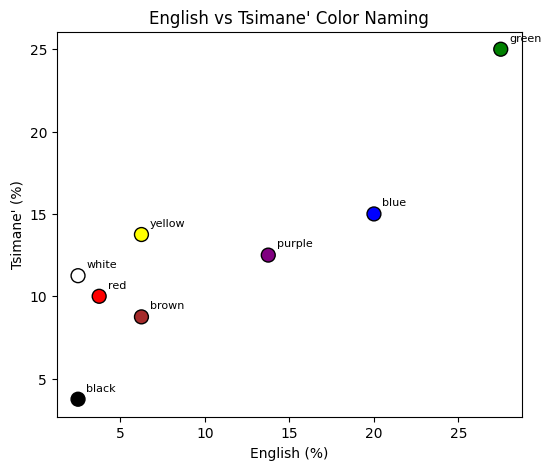

In [ ]:
# Merge de dataframes de español e ingles
eng_tsi = english_pct.merge(tsimane_pct, on='color', suffixes=('_english', '_tsimane'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(eng_tsi['percentage_english'], eng_tsi['percentage_tsimane'],
            c=eng_tsi['color'], edgecolors='black', s=100)

for _, row in eng_tsi.iterrows():
    plt.annotate(row['color'], (row['percentage_english'] + 0.5, row['percentage_tsimane'] + 0.5), fontsize=8)

plt.xlabel('Ingles (%)')
plt.ylabel("Tsimane' (%)")
plt.title("Ingles vs Tsimane")
plt.show()


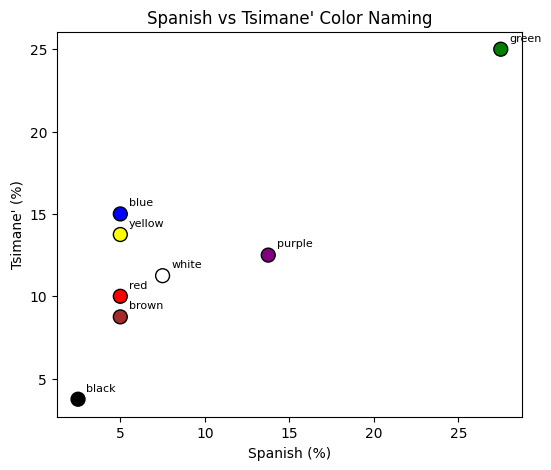

In [ ]:
#Merge de dataframes de Tsimane y Espanñol
spa_tsi = spanish_pct.merge(tsimane_pct, on='color', suffixes=('_spanish', '_tsimane'))

# Scatter plot
plt.figure(figsize=(6, 5))
plt.scatter(spa_tsi['percentage_spanish'], spa_tsi['percentage_tsimane'],
            c=spa_tsi['color'], edgecolors='black', s=100)

for _, row in spa_tsi.iterrows():
    plt.annotate(row['color'], (row['percentage_spanish'] + 0.5, row['percentage_tsimane'] + 0.5), fontsize=8)

plt.xlabel('Español (%)')
plt.ylabel("Tsimane' (%)")
plt.title("Español vs Tsimane")
plt.show()

#Scikit Learn

##Data as table

In [1]:
import seaborn as sns
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


##Target Array

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:2100: UserWarning: The `size` parameter has been renamed to `height`; please update your code.
  warnings.warn(msg, UserWarning)


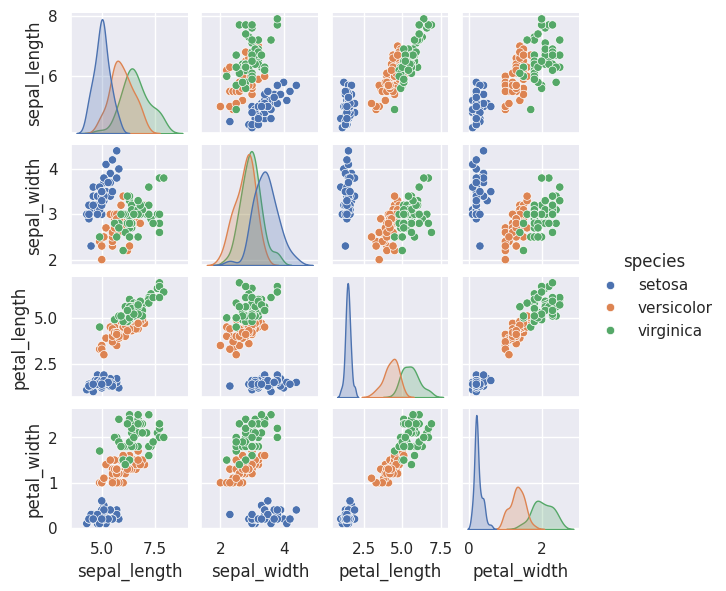

In [2]:
%matplotlib inline
import seaborn as sns; sns.set()
sns.pairplot(iris, hue='species', size=1.5);

In [ ]:
X_iris = iris.drop('species', axis=1)
X_iris.shape